<a href="https://colab.research.google.com/github/Morganjools/PRA3024/blob/main/ML_cifar_CNN_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Some data-handling functions to download/import.

# from https://github.com/yandexdataschool/mlhep2018/blob/master/day2-Tue/seminar-03-keras-cnn/seminar_tf_keras.ipynb
"""I load some cifar"""

import numpy as np
from sklearn.model_selection import train_test_split
import os, sys
if sys.version_info[0] == 2:
    from urllib import urlretrieve
    import cPickle as pickle

else:
    from urllib.request import urlretrieve
    import pickle

def unpickle(file):
    fo = open(file, 'rb')
    if sys.version_info[0] == 2:
        dict = pickle.load(fo)
    else:
        dict = pickle.load(fo,encoding='latin1')

    fo.close()
    return dict




def download_cifar10(path,
                     url='https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz',
                     tarname='cifar-10-python.tar.gz',):
    import tarfile
    if not os.path.exists(path):
        os.mkdir(path)



    urlretrieve(url, os.path.join(path,tarname))
    tfile = tarfile.open(os.path.join(path,tarname))
    tfile.extractall(path=path)


def load_cifar10(data_path=".",channels_last=False,test_size=0.2,random_state=1337):

    test_path = os.path.join(data_path,"cifar-10-batches-py/test_batch")
    train_paths = [os.path.join(data_path,"cifar-10-batches-py/data_batch_%i"%i) for i in range(1,6)]

    if not os.path.exists(test_path) or not all(list(map(os.path.exists, train_paths))):
        print ("Dataset not found. Downloading...")
        download_cifar10(data_path)

    train_batches = list(map(unpickle,train_paths))
    test_batch = unpickle(test_path)

    X = np.concatenate([batch["data"] for batch in train_batches]).reshape([-1,3,32,32]).astype('float32')/255
    y = np.concatenate([batch["labels"] for batch in train_batches]).astype('int32')
    X_train,X_val,y_train,y_val = train_test_split(X,y,
                                                   test_size=test_size,
                                                   random_state=random_state)

    X_test = test_batch["data"].reshape([-1,3,32,32]).astype('float32')/255
    y_test = np.array(test_batch["labels"]).astype('int32')

    if channels_last:
        #convert from [batch,3,H,W] to [batch,H,W,3]
        #WARNING! Make this is only necessary for tensorflow-style dim order
        #If you use theano-style dimensions in keras config, skip this cell
        X_train = X_train.transpose([0,2,3,1])
        X_val   = X_val.transpose([0,2,3,1])
        X_test  = X_test.transpose([0,2,3,1])


    return X_train,y_train,X_val,y_val,X_test,y_test

In [2]:
import tensorflow as tf
#gpu_options = tf.GPUOptions(allow_growth=True, per_process_gpu_memory_fraction=0.1) # restricts GPU load for multi-user nodes

import tensorflow.keras as keras
from keras import backend as K
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
print(tf.__version__)
print(keras.__version__)

2.19.0
3.10.0


In [3]:
# Load the data samples

x_train,y_train,x_val,y_val,x_test,y_test = load_cifar10("cifar_data",channels_last=True)

NUM_CLASSES = 10
cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

print("Train samples:", x_train.shape, y_train.shape)
print("Test samples:", x_test.shape, y_test.shape)
print("Val samples:", x_val.shape, y_val.shape)

Dataset not found. Downloading...


/tmp/ipykernel_2315/3806609017.py:41: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tfile.extractall(path=path)


Train samples: (40000, 32, 32, 3) (40000,)
Test samples: (10000, 32, 32, 3) (10000,)
Val samples: (10000, 32, 32, 3) (10000,)


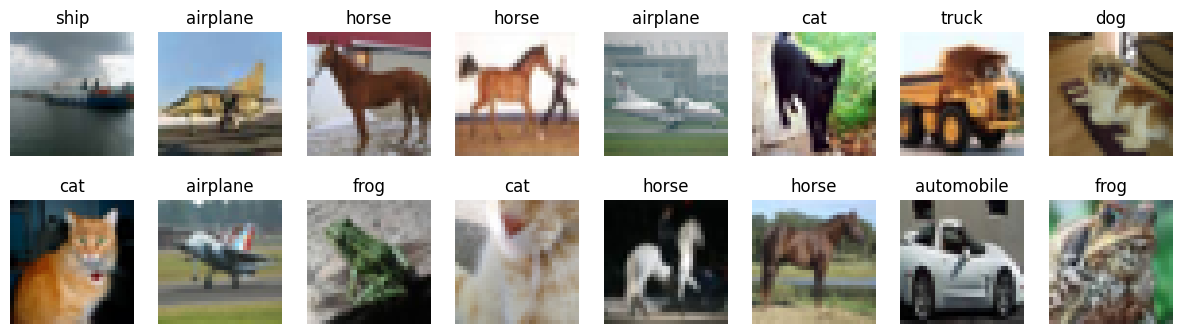

In [4]:
# show some random images from train, and their labels

cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 2.5 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_train))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_train[random_index, :])
        ax.set_title(cifar10_classes[y_train[random_index]])
plt.show()

In [5]:
# normalize inputs
# convert class labels to one-hot encoded, should have shape (?, NUM_CLASSES)
# x_train = x_train.astype(np.float64) - 0.5

y_train = keras.utils.to_categorical(y_train, num_classes=10)

y_val = keras.utils.to_categorical(y_val, num_classes=10)

y_test = keras.utils.to_categorical(y_test, num_classes=10)

In [6]:
# import necessary building blocks
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout
from keras.layers import LeakyReLU

In [ ]:
    #Exercise
    ### STUDENT CODE HERE ###
    ### --> Build your convolutional neural network.
    ### First, make a CNN layer with some small kernels to learn some basic features, with Conv2D.
    ### Then, add a Pooling layer to pick up the relevant kernels.
    ### Then, Flatten it and add some fully-connected (Dense) normal NN layers,
    ###  to learn the relevant combinations of low-level kernel features.
    ### Finally, some regularisation is advised, using a Dropout layer, to avoid local minima.
    ### Make sure the output is of the same shape as the number of labels we have,
    ### And the input is the same as the figures (which now have a 3rd dimension - color!)
    ### Again, use google to find information on these classes.
    ### END STUDENT CODE ###

In [8]:
def make_model():
    """
    Define your model architecture here.
    Returns `Sequential` model.
    """

    #https://keras.io/guides/sequential_model/
    #Sequential model can be used as there is no branching or multiple input or output at any point. There is a straight line from input to output.
    #The model is a stack of layers, with one input and one output tensor.
    model = Sequential()

    #Building CNN; inspiration: https://www.tensorflow.org/tutorials/images/cnn

#Block 1
    #The input are images with size 32x32 with 3 color layers.
    #By adding padding, the size of the feature map will be the same size as the input
    model.add(Conv2D(filters=32, kernel_size=(3, 3), padding='same', input_shape=(32, 32, 3)))

    #Batchnormalization is applied to increase the learning rate (https://keras.io/api/layers/normalization_layers/batch_normalization/)
    model.add(keras.layers.BatchNormalization())

    #Activation function (https://docs.pytorch.org/docs/stable/generated/torch.nn.LeakyReLU.html)
    model.add(LeakyReLU(negative_slope=0.1))

    #Adding second conv2D layer with the same setting to let the model learn more complex combinations of the basic features.
    #Then the same as before; first normalize the output before activating it.
    model.add(Conv2D(filters=32, kernel_size=(3, 3), padding='same'))
    model.add(keras.layers.BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.1))

    #Lowering the size of feature maps by only using the most important features from 2x2 windows
    model.add(MaxPooling2D(pool_size=(2, 2)))

    #Adding a dropout to avoid overfitting of the model
    model.add(Dropout(0.25))

#Block 2
    #By adding more filters, more specific features can be detected. This approach is used in Very Deep CNN (VGG)
    #The other layers are the same as Block 1, but the output of Block 2 has dimensions 8x8
    #Important to note that Block 2 works directly with the output feature maps from Block 1
    model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same'))
    model.add(keras.layers.BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.1))
    model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same'))
    model.add(keras.layers.BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.1))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

#Block 3
    #Doubling the amount of filters to recognize even more details
    #The output of this block has dimensions 4x4
    model.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same'))
    model.add(keras.layers.BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.1))
    model.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same'))
    model.add(keras.layers.BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.1))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

#Flattening the 4x4x128 output into 1x2048 vector for the dense layer
    model.add(Flatten())
    model.add(Dense(units=256))
    model.add(keras.layers.BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.1))

#The same idea as before, but now 50% of the neurons drops out.
#Due to the dense layer, there are now 2048x256 parameters, so much more than Conv2D layer. This means its more prone to overfitting.
    model.add(Dropout(0.5))

#This is the output layer of 10 neurons corresponding to the 10 CIFAR classes.
    model.add(Dense(units=NUM_CLASSES, activation='softmax'))

    return model

#**MARKDOWN STUDENT CODE 1**

Conv2D is the first convolutional layer, that slides matrices (kernels) accross the input data, to produce a new 2D description (feature map). Kernels slide over the input data and perform multiplication and a summation of the results.In this way, kernels are able to extract specific features from the input, such as the edges or textures. The output is a feature map, that show the specific features for which the kernels were used (https://www.geeksforgeeks.org/deep-learning/kernels-filters-in-convolutional-neural-network/). By adding zero-padding, the size of the feature map will be the same as the input, so 32x32 (https://machinecurve.com/index.php/2020/02/10/using-constant-padding-reflection-padding-and-replication-padding-with-keras). This is good, as the output of the first Conv2D layer, is the input of the next one. Specifying that the input shape is 32x32 with 3 colour (RGB) layers. This is only needed for the first layer, as each line builds on the previous. Using batchnormalization solves the internal covariant shift problem (https://www.geeksforgeeks.org/deep-learning/internal-covariant-shift-problem-in-deep-learning/). This happens when the distribution of the input data changes between the training and testing of the model, causing the model to perform badly during testing. As the input data goes through all the layers of the model, the distribution of the layer's input changes. So the layers need to adapt to the changing input distributions. This slows down the learning. Batchnormalization normalizes the outputs of the previous layer, so the mean is a zero and the covariance is 1, before passing them on to the next layer. This makes the learning process faster. Then the LeakyRelu activation function is applied. The relu function ranges from zero to infinity. This means that for any negative value, zero is returned. If the neuron only recieves negative values, the output is zero. To improve this, the LeakyReLu function is applied. Instead of returning zero for the negative values, it returns a small non-zero value. This means that the negative values have a small fixed slope (0.1) that can be recognized (https://www.geeksforgeeks.org/machine-learning/leaky-relu-activation-function-in-deep-learning/). Applying this activation function ensures that the neurons do not become inactive and that the model keeps working.
Then, a second conv2D layer with the same parameters, is added. Stacking these two conv2D layers helps the model regocnize more complex combinations of the basic features better. The output is still the same size as the input, due to the padding. To this output, maxpooling is applied to decrease the size (https://keras.io/api/layers/pooling_layers/max_pooling2d/). It is an operation on 2D spatial data that decreases the size of the feature maps along the spatial dimensions (32x32). It takes the maximum value over the window, specified as pool_size in the function. In this case the window is set to 2x2 blocks. These maximum values correlate to the most important features of the window, such as edges. Maxpooling is mostly done to decrease the dimensions of the feature maps (32x32 -> 16x16) to reduce computational load and memory use.
The last layer that is added, is the dropout(0.25) (https://machinelearningmastery.com/dropout-regularization-deep-learning-models-keras/). This function is used to reduce overfitting, by randomly ignoring 25% (in this case) of neurons during the training of the model. In a model, neurons might get 'specialized' for specific feature recognition. The other neurons might rely too much on this and this can lead to the model becoming too specialized for the training data (overfitting). By setting 25% of neurons to zero, other neurons have to take over, and the model becomes more aware of general features. Overfitting can be recognized if the training accuracy is very high and the testing accuracy low (https://medium.com/@vishnuam/dropout-in-convolutional-neural-networks-cnn-422a4a17da41).

Block 2 and Block 3 have the same layers as Block 1. The only differences are the amount of filters in the Conv2D layers and that these blocks work with the output feature maps from the previous blocks. By adding more filters, the model can recognize more details and specific features. This technique is used in Very Deep Convolutional Networks (VGG) (https://viso.ai/deep-learning/vgg-very-deep-convolutional-networks/). In this technique, the number of filters doubles after each stack of convolutional layers, in this case the blocks. These additional filters recognize more complex combinations of the feature maps from the previous blocks. So, for example, the filters in Block 1 recognize edges and colours, the filters in Block 2 then recognize shapes and the filters in Block 3 even more specific details (eyes or fur). More filters are used in Block 2 and 3, as the input dimensions are smaller. Applying more filters to Block 1, with input of dimensions 32x32, will take too long to run. So the smaller the input dimensions, the more layers can be applied to decrease computation time.
The final output from Block 3 has dimensions 4x4 due to applying the maxpooling 3 times on input of dimensions 32x32.

For the last step, it is important to discuss the dimension of the outputs of the blocks. The spatial dimensions go: 32x32 -> 16x16 -> 8x8 -> 4x4. The colours (depth) of the images is more difficult. At the start, each colour (RGB) has 32x32 values. In the first block, the 32 filters scan all three colour layers and creating its own 32x32 feature map. So at the end of Block 1, the depth is 32 (for each filter). So the final dimensions after Block 2 are: 4x4x128.

Flattening is used to convert multidimensional outputs into a single dimensional vector. This is needed for the dense layer, as it cannot work with a 3-dimensional input. So the 4x4x128 output becomes a 1x2048 vector.

Then the dense layer connects the 2048 inputs to the 256 neurons (units=256). The 256 neurons compress the 2048-dimensional vector into a 256-dimensional representation, by forming connections between the 2048 values, so that the model recognize connections between features. More neurons were added so that the model recognizes more complex, non-linear features. This does take more computation time. Before the final layer, another dropout is added. Now 50% of neurons drop out, as there are way more parameters than before. This causes it to be more prone to overfitting.

The final step is the output layer. The output layer needs to have 10 neurons (NUM_CLASSES). This corresponds to the 10 classes of the CIFAR-10 dataset (https://www.cs.toronto.edu/~kriz/cifar.html). The 'softmax' activation function converts the 10 raw scares into probabilities adding up to 1. So the output is 10 probabilities that correspond to the classes. The highest value class corresponds to the prediction (https://www.geeksforgeeks.org/deep-learning/the-role-of-softmax-in-neural-networks-detailed-explanation-and-applications/).  

**NEXT EXERCISE**


In [10]:
#Data augmentation to create additional training data, by making believable images from the existing ones.
#Augmentation only applies during training, not testing
#https://www.tensorflow.org/tutorials/images/data_augmentation
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),          #Flipping the image left or right
    keras.layers.RandomTranslation(0.1, 0.1),       #Small shifts in x and y
    keras.layers.RandomRotation(0.1),               #Small rotations
    keras.layers.RandomZoom(0.1),                   #Zoom in or out
], name="data_augmentation")


#https://keras.io/2/api/optimizers/adam/
#The adam algorithm implements the stochastic gradient descent method.
#The default intitial learning rate is 0.001
INIT_LR = 1e-3
BATCH_SIZE = 64     #Used for SGD
EPOCHS = 50         #Number of times the model will go over the dataset

#Clears all states created by keras. All the models are stored in graphs that would become too cluttered for large models and datasets.
#To decrease memory, the clear session function removes the graphs and starts anew and frees up memory (https://stackoverflow.com/questions/50895110/what-do-i-need-k-clear-session-and-del-model-for-keras-with-tensorflow-gpu)
#Make model creates a new graph.
K.clear_session()
model = make_model()

#https://carpentries-incubator.github.io/intro-image-classification-cnn/04-fit-cnn.html
#The optimizer is the function with which the model learns to optimize the loss function (minimize the model error). In this case Adam.
model.compile(
    loss='categorical_crossentropy',  # we train 10-way classification
    optimizer=keras.optimizers.Adam(learning_rate=INIT_LR),  # for SGD.
    metrics=['accuracy'] # report accuracy during training
)

# Print model summary. Shows network layout, and # free parameters (weights + biases) to adapt while learning.
model.summary()

#To see how well the model works with the test dataset, without training.
#It's probably random: so for 10 digits, it should get an accuracy around 0.1 .
loss, accuracy = model.evaluate(x_test, y_test, verbose=False)
print(f'Test loss before training:    {loss:.3f}')
print(f'Test accuracy before training: {accuracy:.3f}')


#To improve training:
#https://keras.io/api/callbacks/reduce_lr_on_plateau/
#Decreasing the learning rate after 5 stagnating epochs (patience=5)
lr_scheduler = keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

#https://keras.io/api/callbacks/early_stopping/
#Stops training when the model has stopped improving
#Restor best weights to obtain the weights from the best epoch, not the last epoch
early_stopping = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)

#Fitting the model
#This will train the model by slicing the data into batches and going over the entire dataset 50 times
history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=[lr_scheduler, early_stopping],
    shuffle=True,
)

# save weights to file to avoid re-training
model.save_weights("myweights.weights.h5")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 8, 8, 128)      │             

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

Test loss before training:    2.303
Test accuracy before training: 0.097
Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.3572 - loss: 1.8699 - val_accuracy: 0.5255 - val_loss: 1.4325 - learning_rate: 0.0010
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6097 - loss: 1.0930 - val_accuracy: 0.6298 - val_loss: 1.1130 - learning_rate: 0.0010
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6876 - loss: 0.8861 - val_accuracy: 0.6860 - val_loss: 0.8879 - learning_rate: 0.0010
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7246 - loss: 0.7820 - val_accuracy: 0.7324 - val_loss: 0.7430 - learning_rate: 0.0010
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7480 - loss: 0.7160 - val_accuracy: 0.7284 - val_loss: 0.7727 - learning_rate: 0.0010
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7721 - loss: 0.6537 - val_accuracy: 0.7345 - val_loss: 0.7944 - learning_rate: 0.0010
Epoch 7/

#**MARKDOWN STUDENT CODE 2**

This is the training of the model. First, the data augmentation function is applied. Data augmentation generates additional training data from the existing images by applying random transformations that yield new, transformed images, expanding the training set. This helps expose the model to more aspects of the data, by increasing the diversity of the training set (https://www.tensorflow.org/tutorials/images/data_augmentation). The 'tf.keras.layers.RandomFlip' function is used to flip the image horizontally, as this makes the most sense for the CIFAR dataset. It is important that the model recognizes animals, whether they are one the left or right side of the image. 'tf.keras.layers.RandomTranslation' is used to shift the image, either up or to the side (x or y direction) with 10% of the image size, so about 3 pixels (32x32) (https://www.tensorflow.org/api_docs/python/tf/keras/layers/RandomTranslation). 'tf.keras.layers.RandomRotation' is used to rotate the image by an angle, in this case 10% of 360 degrees (https://www.tensorflow.org/api_docs/python/tf/keras/layers/RandomRotation). It trains the model that objects can be tilted. 'tf.keras.layers.RandomZoom' is used to zoom in or out by 10% of the image size, so the model recognizes the features at different scales (https://www.tensorflow.org/api_docs/python/tf/keras/layers/RandomZoom).

In this training model, the Adam algorithm is implemented. Adam optimization is a stochastic gradient descent method (https://keras.io/2/api/optimizers/adam/). SGD is usually implemented when working with large datasets. The large dataset is divided into batches (size=64) and the gradient of the subsets is calculated, instead of the gradient of the entire dataset. This makes the computation faster. The goal is to find the minimum, so the smallest error, by finding the steepest descent direction, by calculating the gradient of the small batches. The smaller the batch the less accurate the gradient. Therefor, 64 is a good batch size (https://stackoverflow.com/questions/35050753/how-big-should-batch-size-and-number-of-epochs-be-when-fitting-a-model).
The number of epochs is the amount of times the model goes over the full dataset. So in this case, the model will see the dataset 50 times.

It is then neccessary to compile the model, so set up how the model will learn, with the 'model.compile' function (https://carpentries-incubator.github.io/intro-image-classification-cnn/04-fit-cnn.html). The optimizer is the way the model will minimize the error, in this case with the Adam algorithm. The loss function tells the model how far away from the predicted value it is, and the goal is to minimize the error. In this model the categorical cross entropy loss function is used. The output of the network is a list of 10 probabilities, for the 10 different classes, that sum to 1. However, the true label has a list of zero's with one 1, which is the correct answer. So to measure how wrong the prediction is, so the model knows how wrong it was and how to correct itself, the loss function is used. The lower the value of the loss function, the better the prediction of the model (https://keras.io/api/losses/probabilistic_losses/#categoricalcrossentropy-class).

The test accuracy before training was found to be 0.097, so around 0.1. This is expected as there are 10 images, so randomly assigning them will give a probability of 10% being correct (https://stackoverflow.com/questions/59840289/model-evaluate-in-keras).

To improve training, ReduceLROnPlateau and early stopping functions are applied. The ReduceLROnPlateau function reduces the learning rate when the model has stopped improving. This function reduces the learning rate after 5 epochs of no improvements (patience=5) (https://keras.io/api/callbacks/reduce_lr_on_plateau/). Monitor is the parameter that needs to be watches, so in this case the validation accuracy. If that doesn't improve after 5 epochs, the learning rate is reduced. Factor=0.5 is the number by which the learning rate is multiplied after a stagnation. Min_lr is the lowest value the learning rate is allowed to be reduced to, lower than this is not possible. Lastly, verbose prints a message when the learning rate is lowered, not necessary, but interesting to observe.

Early stopping monitors the model's performance on a test set. The training is stopped when the validation loss stops decreasing, to find the moment of best performance. It is a way to stop overfitting, as it stops before increasing validation loss (https://www.geeksforgeeks.org/deep-learning/using-early-stopping-to-reduce-overfitting-in-neural-networks/).

Lastly, the model is fitted, this is used for the learning curves as it records the loss and accuracy. If this is not done, the history is lost after all the training (https://keras.io/guides/training_with_built_in_methods/). x_train and y_train is the data from which the model learns. Batch size is the number of images at a time before the weights are updated. After each epoch, the model tests itself on the validation data, x_val and y_val. This shows how well the model is trained and can work with other data besides the training data. The callbacks measure the accuracy of the model based on its performance with the validation data. And the shuffle randomly shuffles the training data, so the network doesn't learn any patterns (https://keras.io/guides/training_with_built_in_methods/).

**END**



In [11]:
# load weights from file (can call without model.fit)
model.load_weights("myweights.weights.h5")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


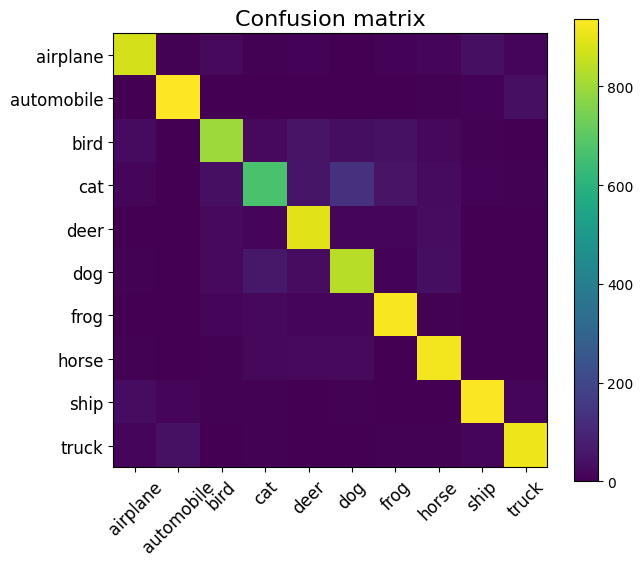

Test accuracy: 0.8698


In [12]:
# make test predictions
y_pred_test = model.predict(x_test)
y_pred_test_classes = np.argmax(y_pred_test, axis=1)
y_pred_test_max_probas = np.max(y_pred_test, axis=1)
y_test_index = [list(onehot).index(1) for onehot in y_test]

# confusion matrix and accuracy
from sklearn.metrics import confusion_matrix, accuracy_score
plt.figure(figsize=(7, 6))
plt.title('Confusion matrix', fontsize=16)
plt.imshow(confusion_matrix(y_test_index, y_pred_test_classes))
plt.xticks(np.arange(10), cifar10_classes, rotation=45, fontsize=12)
plt.yticks(np.arange(10), cifar10_classes, fontsize=12)
plt.colorbar()
plt.show()
print("Test accuracy:", accuracy_score(y_test_index, y_pred_test_classes))

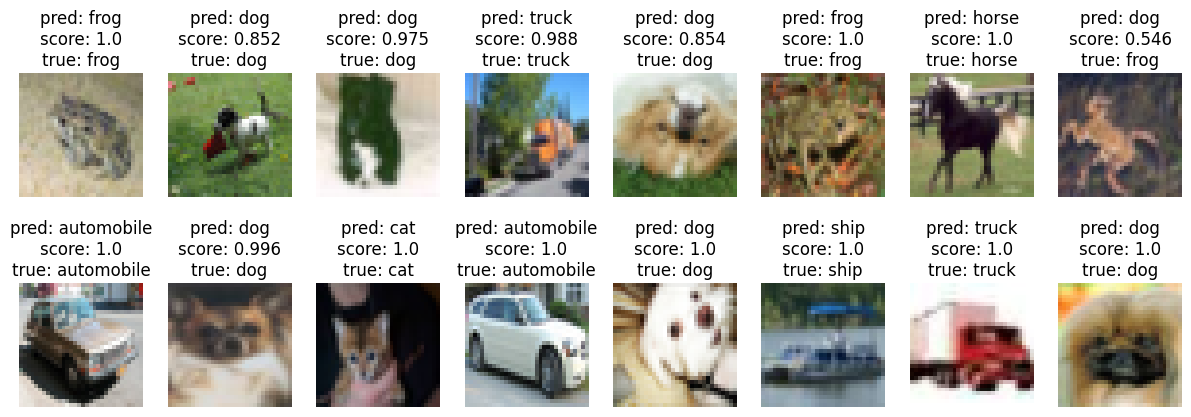

In [13]:
# inspect preditions
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 3 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_test))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_test[random_index, :])
        pred_label = cifar10_classes[y_pred_test_classes[random_index]]
        pred_proba = y_pred_test_max_probas[random_index]
        true_label = cifar10_classes[y_test_index[random_index]]
        ax.set_title("pred: {}\nscore: {:.3}\ntrue: {}".format(
               pred_label, pred_proba, true_label
        ))
plt.show()

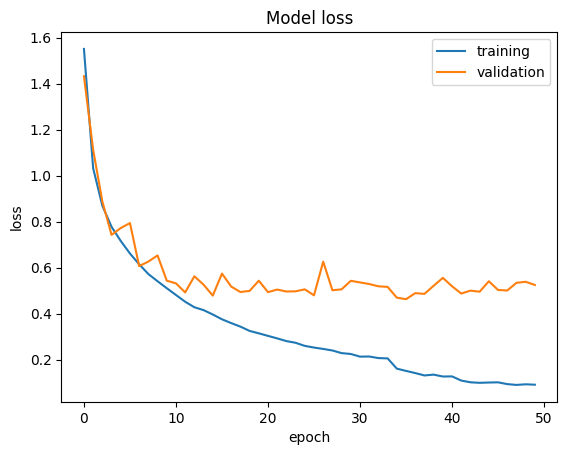

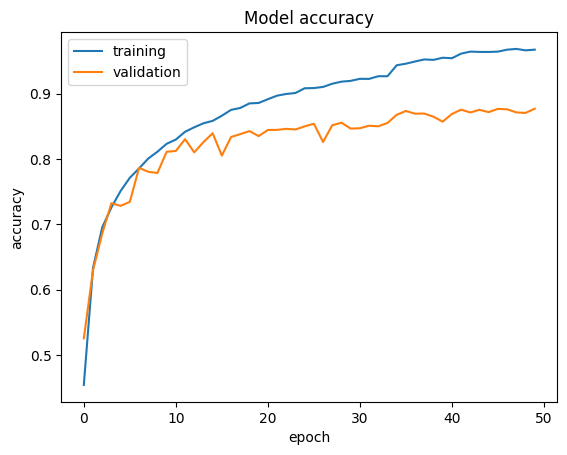

In [14]:
#Plotting the progression of the training loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['training', 'validation'], loc='best')
plt.show()

#Plotting the progression of the training accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training', 'validation'], loc='best')
plt.show()

#**MARKDOWN PLOTS**

The bottom plot shows that the training accuracy reaches about 96% and the validation accuracy around 85%. These are good results. However, there is a clear gap between the training and validation data, as seen in both plots. In the beginning the curves are even, but they diverge later, so the model performs better on seen data than unseen data. This could be due to overfitting, as maybe the model is too used to the training data. It might be memorizing the training data instead of generalising.

Also, the early-stopping didn't trigger. This is because after epoch 25-ish the curves flatten. So the accuracy might still be increasing, but very little. So to improve, the trigger for the early stopping might have to come sooner to decrease overfitting.

To improve, maybe more data augmentation could be added to make the training more difficult for the model and it becomes more general.

**END**

# Some tips on how to improve:

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.

## Potential grading:
* starting at zero points
* +2 for describing your iteration path in a report below.
* +2 for building a network that gets above 20% accuracy
* +1 for beating each of these milestones on __TEST__ dataset:
    * 50% (5 total)
    * 60% (6 total)
    * 65% (7 total)
    * 70% (8 total)
    * 75% (9 total)
    * 80% (10 total)

## Bonus points
Common ways to get bonus points are:
* Get higher score, obviously.
* Anything special about your NN. For example \"A super-small/fast NN that gets 80%\" gets a bonus.
* Any detailed analysis of the results. (saliency maps, whatever)


## Tips on what can be done:

 * __Network size__
   * More neurons,
   * More layers, ([lasagne docs](http://lasagne.readthedocs.org))
   * Nonlinearities in the hidden layers
   * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

 * __Convolution layers__
   * they __are a must__ unless you have any super-ideas
   * `network = lasagne.layers.Conv2DLayer(prev_layer,`
     `                       num_filters = n_neurons,`
     `                       filter_size = (filter width, filter height),`
     `                       nonlinearity = some_nonlinearity)`
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment to try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   * Plenty other layers and architectures
     * http://lasagne.readthedocs.org/en/latest/modules/layers.html
     * batch normalization, pooling, etc


 * __Early Stopping__
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum


 * __Faster optimization__ -
   * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (lasagne.layers.batch_norm) FTW!


 * __Regularize__ to prevent overfitting
   * Add some L2 weight norm to the loss function, theano will do the rest
     * Can be done manually or via - http://lasagne.readthedocs.org/en/latest/modules/regularization.html
   * Dropout - to prevent overfitting
     * `lasagne.layers.DropoutLayer(prev_layer, p=probability_to_zero_out)`   
     * Don't overdo it. Check if it actually makes your network better


 * __Data augmentation__ - getting 5x as large dataset for free is a great deal
   * Zoom-in+slice = move
   * Rotate+zoom(to remove black stripes)
   * any other perturbations
   * Add Noize (easiest: GaussianNoizeLayer)
   * Simple way to do that (if you have PIL/Image):
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.


